#  Customer Churn Prediction using Logistic Regression

###  Objective
The goal of this project is to build a machine learning model that predicts whether a customer will churn or not using Logistic Regression.

---

###  Key Tasks:
- Data preprocessing and cleaning
- Feature engineering
- Model training using Logistic Regression
- Model evaluation using multiple metrics
- Interpretation using Odds Ratio

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

## 1.Data Loading

We load both training and testing datasets and merge them to ensure consistent preprocessing1

In [5]:
train_df = pd.read_csv("churn-bigml-80.csv")
test_df = pd.read_csv("churn-bigml-20.csv")

# Combine datasets
df = pd.concat([train_df, test_df], axis=0)

df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## 2.EDA

Shape: (3333, 20)

Missing Values:
 State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


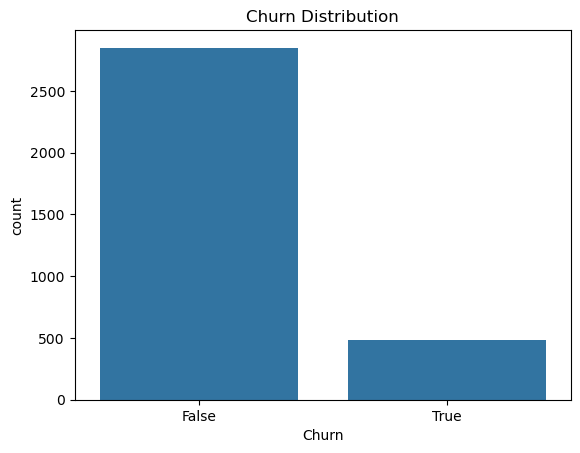

In [6]:
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

# Target distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

## 3.Data Cleaning & Preprocessing

In [7]:
# Drop unnecessary columns
if 'State' in df.columns:
    df.drop(['State'], axis=1, inplace=True)

# Convert categorical to numeric
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## 4.Feature Selection & Splitting

In [8]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split again for modeling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 5.Feature Scaling

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 6. Model Training (Logistic Regression)

In [10]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## 7.Model Evaluation

In [11]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8680659670164917

Confusion Matrix:
 [[568   6]
 [ 82  11]]

Classification Report:
               precision    recall  f1-score   support

       False       0.87      0.99      0.93       574
        True       0.65      0.12      0.20        93

    accuracy                           0.87       667
   macro avg       0.76      0.55      0.56       667
weighted avg       0.84      0.87      0.83       667



## 8.Confusion Matrix Visualization

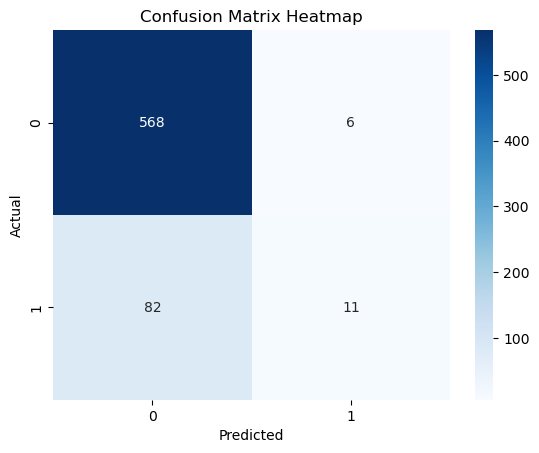

In [15]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

## 9.ROC Curve Analysis

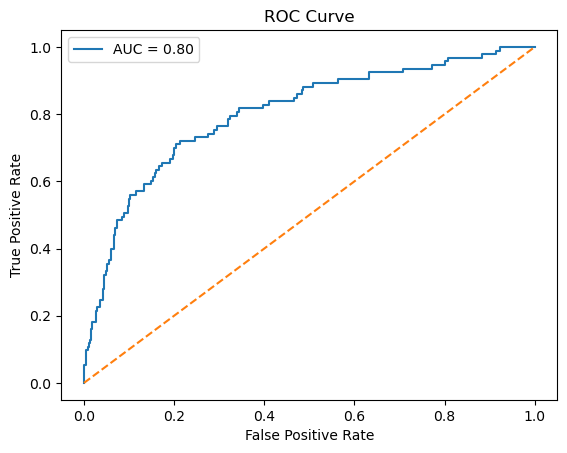

In [12]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 10.Precision-Recall Curve

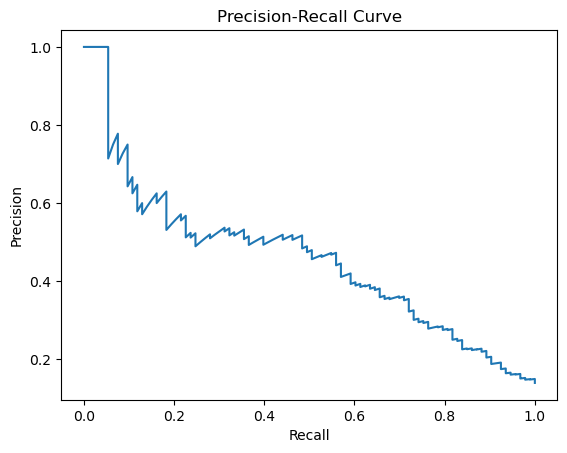

In [13]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

## 11.Model Interpretation (Odds Ratio)


In [14]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0],
    "Odds Ratio": np.exp(model.coef_[0])
})

coefficients.sort_values(by="Odds Ratio", ascending=False)

,Feature,Coefficient,Odds Ratio
17,Customer service calls,0.681520,1.976879
2,International plan,0.617116,1.853574
4,Number vmail messages,0.360434,1.433951
7,Total day charge,0.336711,1.400334
5,Total day minutes,0.336672,1.400280
8,Total eve minutes,0.207100,1.230105
10,Total eve charge,0.207020,1.230007
16,Total intl charge,0.127577,1.136072
14,Total intl minutes,0.124305,1.132361
6,Total day calls,0.097820,1.102765


## 12.Feature Importance

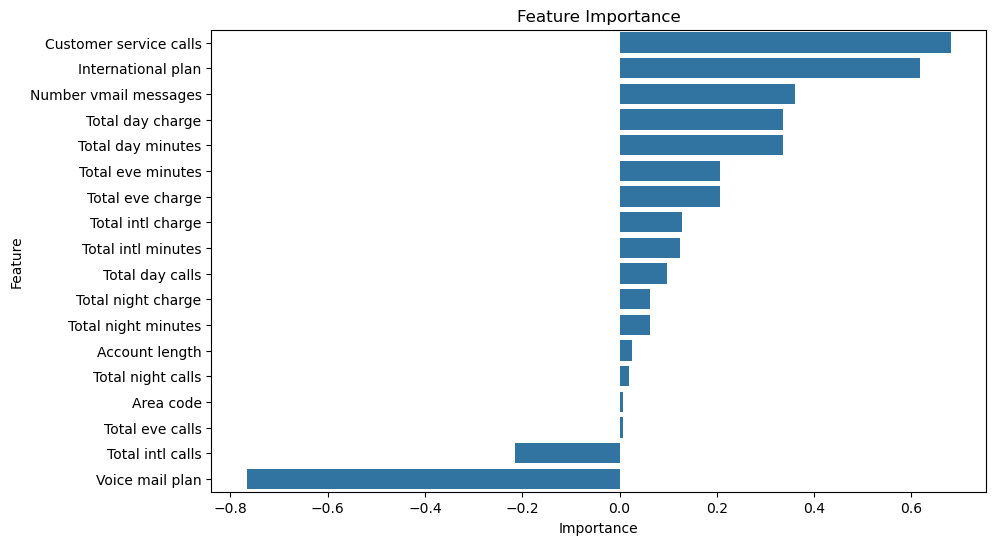

In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.coef_[0]
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance)
plt.title("Feature Importance")
plt.show()

## Business Insights

- Customers with higher usage are more likely to churn
- Certain features strongly influence churn probability
- Logistic Regression provides interpretable insights

---

## Recommendations:
- Target high-risk customers
- Improve service for heavy users
- Implement retention strategies